# Day 3 — Dimensionality Reduction with PCA

In this task, we apply Principal Component Analysis (PCA) to the Breast Cancer Wisconsin dataset.

The main goals are to:
- Standardize the numerical features.
- Apply PCA and analyze the explained variance.
- Determine the number of components needed to retain approximately 95% of the variance.
- Reduce the dataset from 30 features to 10 components.
- Reduce the data to 2 components for visualization.
- Analyze what PCA preserved and what was lost during dimensionality reduction.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Loading and Initial Inspection

First, we load the dataset and inspect its structure, shape, data types, missing values, and duplicate rows.

This initial inspection helps us understand the dataset and identify any unnecessary columns or data quality issues before applying preprocessing.

In [3]:
df = pd.read_csv("data.csv")
print( df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### Dataset Information

The info() method is used to inspect the data types, number of non-null values, and overall structure of the dataset.

The dataset contains 569 samples and 33 columns, including the target variable, an ID column, 30 numerical features, and an empty column named Unnamed: 32.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.duplicated().sum()


np.int64(0)

## Preparing Features and Target

The id column is removed because it is only an identifier and does not represent a meaningful feature.

The Unnamed: 32 column is also removed because it contains no useful information.

The diagnosis column is separated as the target variable. PCA is applied only to the 30 numerical features and does not use the target labels.

In [7]:
X = df.drop(["id", "Unnamed: 32", "diagnosis"], axis =1 )
y = df["diagnosis"]

In [8]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


## Step 1 — Feature Scaling

PCA is variance-based, so the numerical features must be standardized before applying PCA.

Without scaling, features with larger numerical ranges could dominate the principal components simply because of their scale.

StandardScaler transforms each feature to have approximately:
- Mean = 0
- Standard deviation = 1

In [9]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

## Step 2 — Fitting PCA and Analyzing Explained Variance

We first fit PCA without specifying n_components. This keeps all 30 components and allows us to examine how much variance each component explains.

The explained variance ratio will help us determine how many components should be retained.

In [11]:
pca = PCA()

X_pca = pca.fit_transform(X_scaler)

In [13]:
print("Original shape:", X_scaler.shape)
print("PCA shape:", X_pca.shape)

Original shape: (569, 30)
PCA shape: (569, 30)


### Explained Variance Ratio

The explained variance ratio indicates the proportion of the total variance captured by each principal component.

The first principal component captures the largest amount of variance, followed by the second component, and so on.

In [14]:
print(pca.explained_variance_ratio_)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [15]:
cumulative_variance = pca.explained_variance_ratio_.cumsum()

print(cumulative_variance)

[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


### Component Selection:
The first 10 principal components retain approximately 95.16% of the total variance. Therefore, 10 components were selected as a balance between dimensionality reduction and information preservation. This reduces the feature space from 30 original features to 10 principal components while retaining most of the variance in the dataset.

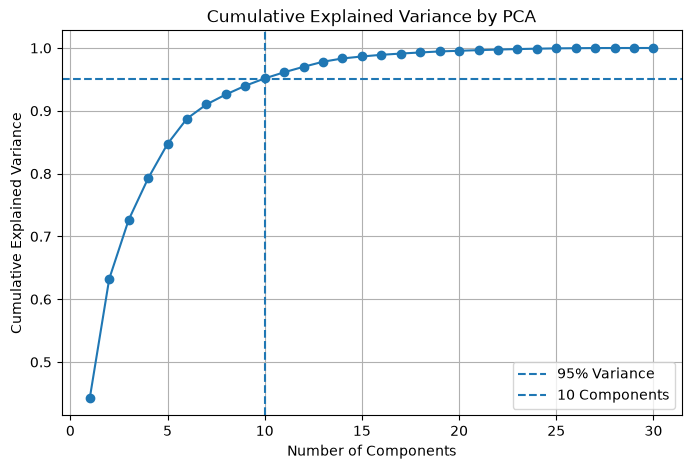

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=10,
    linestyle="--",
    label="10 Components"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA")
plt.legend()
plt.grid()
plt.show()

## Step 3 — Choosing the Number of Components

The first 10 principal components retain approximately 95.16% of the total variance.

Therefore, 10 components are selected as a balance between dimensionality reduction and information preservation.

This reduces the feature space from 30 original features to 10 principal components while retaining most of the variance.

In [20]:
pca_10 = PCA(n_components = 10)
X_pca_10 = pca_10.fit_transform(X_scaler)

In [21]:
print( "Total explained variance:",pca_10.explained_variance_ratio_.sum())

Total explained variance: 0.9515688143366667


## Step 4 — Reducing to 2 Components for Visualization

A separate PCA model with two components is fitted for visualization purposes.

The goal here is not to retain 95% of the variance, but to represent the high-dimensional dataset in two dimensions so that its structure can be visualized using a scatter plot.

In [22]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaler)

In [23]:
print("Original shape:", X.shape)
print("2D PCA shape:", X_pca_2.shape)

Original shape: (569, 30)
2D PCA shape: (569, 2)


In [24]:
print("Explained variance ratio:", pca_2.explained_variance_ratio_)
print("Total variance retained:", pca_2.explained_variance_ratio_.sum())

Explained variance ratio: [0.44272026 0.18971182]
Total variance retained: 0.6324320765155944


### 2D PCA Visualization

The two principal components are plotted on the x-axis and y-axis.

The diagnosis labels are used only to color the observations as Benign (B) or Malignant (M).

The labels are not used when fitting PCA because PCA is an unsupervised dimensionality reduction technique.

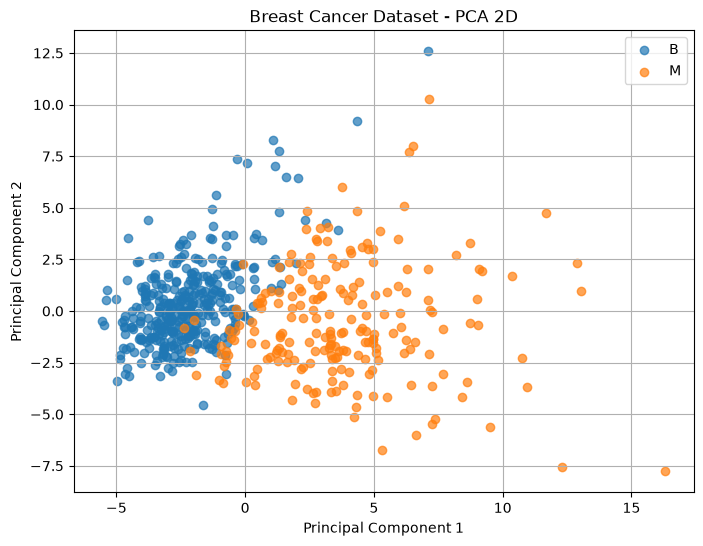

In [25]:
plt.figure(figsize=(8, 6))

for diagnosis in ["B", "M"]:
    mask = y == diagnosis
    
    plt.scatter(
        X_pca_2[mask, 0],
        X_pca_2[mask, 1],
        label=diagnosis,
        alpha=0.7
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Dataset - PCA 2D")
plt.legend()
plt.grid()
plt.show()

## Step 5 — What PCA Preserved and What It Cost

Using 10 components reduced the feature space from 30 original features to 10 components while retaining 95.16% of the total variance.

This provides substantial dimensionality reduction while preserving most of the information in the dataset.

However, PCA comes with a loss of interpretability because each principal component is a combination of the original features rather than a single meaningful feature.

For visualization, reducing the data to 2 components retained 63.24% of the variance. This resulted in some information loss, but it allowed the data to be represented in a 2D scatter plot.

Overall, PCA provides a useful trade-off between dimensionality reduction, information preservation, and interpretability.